<a href="https://colab.research.google.com/github/vaghaninayan/nayan-portfolio/blob/main/AWCA_Phase2_TrashNet_DriveReady.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data-Driven Analysis of Waste Management Efficiency Using Machine Learning

**Student Name:** Nayanbhai Vaghani  
**Course:** Project: Computer Science Project (DLMDSPDSUC01)  
**University:** IU International University of Applied Sciences  
**Phase:** Phase 2  
**Implementation Environment:** Google Colab

## Objective of Phase 2 Implementation

This notebook presents the practical implementation of the Automated Waste Classification Analysis (AWCA) system.

The implementation includes:
- dataset preparation using TrashNet
- train, validation, and test split
- preprocessing and augmentation
- Baseline CNN implementation
- MobileNetV2 transfer learning
- ResNet50 transfer learning
- evaluation using accuracy, precision, recall, F1-score, and confusion matrix

## Development Environment

The implementation is executed in Google Colab using Python, TensorFlow, Keras, NumPy, Matplotlib, Pillow, and Scikit-learn. GPU support is used when available to reduce the training time of deep learning models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Project Directory Structure

Separate folders are created for working data, split datasets, saved figures, reports, and trained models. This improves reproducibility and keeps the implementation organized.

In [ ]:
PROJECT_DIR = "/content/waste_phase2_project"
MERGED_DIR = os.path.join(PROJECT_DIR, "merged_dataset")
SPLIT_DIR = os.path.join(PROJECT_DIR, "split_dataset")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")

for path in [PROJECT_DIR, MERGED_DIR, SPLIT_DIR, OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    os.makedirs(path, exist_ok=True)

print("Folders created successfully.")
print("Project directory:", PROJECT_DIR)

Folders created successfully.
Project directory: /content/waste_phase2_project


## Dataset Acquisition

This study uses the TrashNet dataset, which is already extracted and stored in Google Drive. The dataset contains six waste categories:
- cardboard
- glass
- metal
- paper
- plastic
- trash

In [ ]:
TRASHNET_DIR = "/content/drive/MyDrive/west_project/datasets/trashnet/dataset-resized"

print("Dataset path:", TRASHNET_DIR)
print("Exists:", os.path.exists(TRASHNET_DIR))
print("Classes:", os.listdir(TRASHNET_DIR))

Dataset path: /content/drive/MyDrive/west_project/datasets/trashnet/dataset-resized
Exists: True
Classes: ['paper', 'plastic', 'metal', 'trash', '.DS_Store', 'cardboard', 'glass']


## Dataset Preparation Strategy

The dataset is copied into a unified working directory to ensure consistent preprocessing and reproducibility throughout the experiment.

In [ ]:
FINAL_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Clean previous copied data if present
if os.path.exists(MERGED_DIR):
    shutil.rmtree(MERGED_DIR)
os.makedirs(MERGED_DIR, exist_ok=True)

for cls in FINAL_CLASSES:
    src_dir = os.path.join(TRASHNET_DIR, cls)
    dst_dir = os.path.join(MERGED_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    for file in Path(src_dir).glob("*"):
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            shutil.copy(str(file), os.path.join(dst_dir, file.name))

print("Dataset copied successfully.")

Dataset copied successfully.


## Class Distribution

The number of images in each class is checked to verify that the dataset has been copied correctly and to document class distribution.

In [ ]:
print("Dataset size by class:\n")
for cls in FINAL_CLASSES:
    cls_dir = os.path.join(MERGED_DIR, cls)
    print(cls, ":", len(os.listdir(cls_dir)))

Dataset size by class:

cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


## Sample Images from the Dataset

One sample image from each class is displayed to verify visual correctness of the dataset structure.

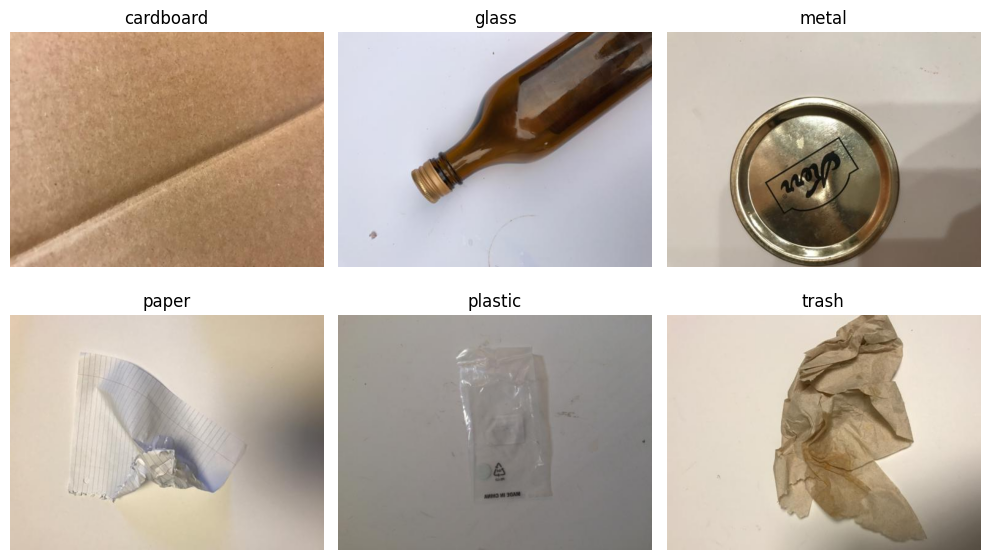

In [ ]:
plt.figure(figsize=(10, 6))
i = 1

for cls in FINAL_CLASSES:
    cls_dir = os.path.join(MERGED_DIR, cls)
    img_name = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_name)

    img = Image.open(img_path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

## Reproducibility Setup

A fixed random seed is used to ensure reproducibility of dataset splitting and model training.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Random seed fixed:", SEED)

Random seed fixed: 42


## Data Splitting Strategy

The dataset is divided into:
- 70% training set
- 15% validation set
- 15% testing set

In [ ]:
def split_dataset(source_dir, target_dir, class_names):
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)

    for split in ["train", "val", "test"]:
        for cls in class_names:
            os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

    for cls in class_names:
        cls_dir = os.path.join(source_dir, cls)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(files)

        n = len(files)
        train_end = int(n * 0.70)
        val_end = train_end + int(n * 0.15)

        train_files = files[:train_end]
        val_files = files[train_end:val_end]
        test_files = files[val_end:]

        for f in train_files:
            shutil.copy(os.path.join(cls_dir, f), os.path.join(target_dir, "train", cls, f))
        for f in val_files:
            shutil.copy(os.path.join(cls_dir, f), os.path.join(target_dir, "val", cls, f))
        for f in test_files:
            shutil.copy(os.path.join(cls_dir, f), os.path.join(target_dir, "test", cls, f))

        print(f"{cls}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

split_dataset(MERGED_DIR, SPLIT_DIR, FINAL_CLASSES)

cardboard: train=282, val=60, test=61
glass: train=350, val=75, test=76
metal: train=287, val=61, test=62
paper: train=415, val=89, test=90
plastic: train=337, val=72, test=73
trash: train=95, val=20, test=22


In [ ]:
for split in ["train", "val", "test"]:
    print(f"\n--- {split.upper()} ---")
    split_path = os.path.join(SPLIT_DIR, split)
    for cls in FINAL_CLASSES:
        cls_dir = os.path.join(split_path, cls)
        print(cls, ":", len(os.listdir(cls_dir)))


--- TRAIN ---
cardboard : 282
glass : 350
metal : 287
paper : 415
plastic : 337
trash : 95

--- VAL ---
cardboard : 60
glass : 75
metal : 61
paper : 89
plastic : 72
trash : 20

--- TEST ---
cardboard : 61
glass : 76
metal : 62
paper : 90
plastic : 73
trash : 22


## Data Loading

The train, validation, and test datasets are loaded using TensorFlow's image dataset pipeline. All images are resized to 224 × 224 pixels.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = os.path.join(SPLIT_DIR, "train")
val_dir = os.path.join(SPLIT_DIR, "val")
test_dir = os.path.join(SPLIT_DIR, "test")

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Detected classes:", class_names)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Detected classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Data Augmentation and Preprocessing

Data augmentation is applied only to the training set to improve generalization. Three preprocessing pipelines are used for the baseline CNN, MobileNetV2, and ResNet50.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

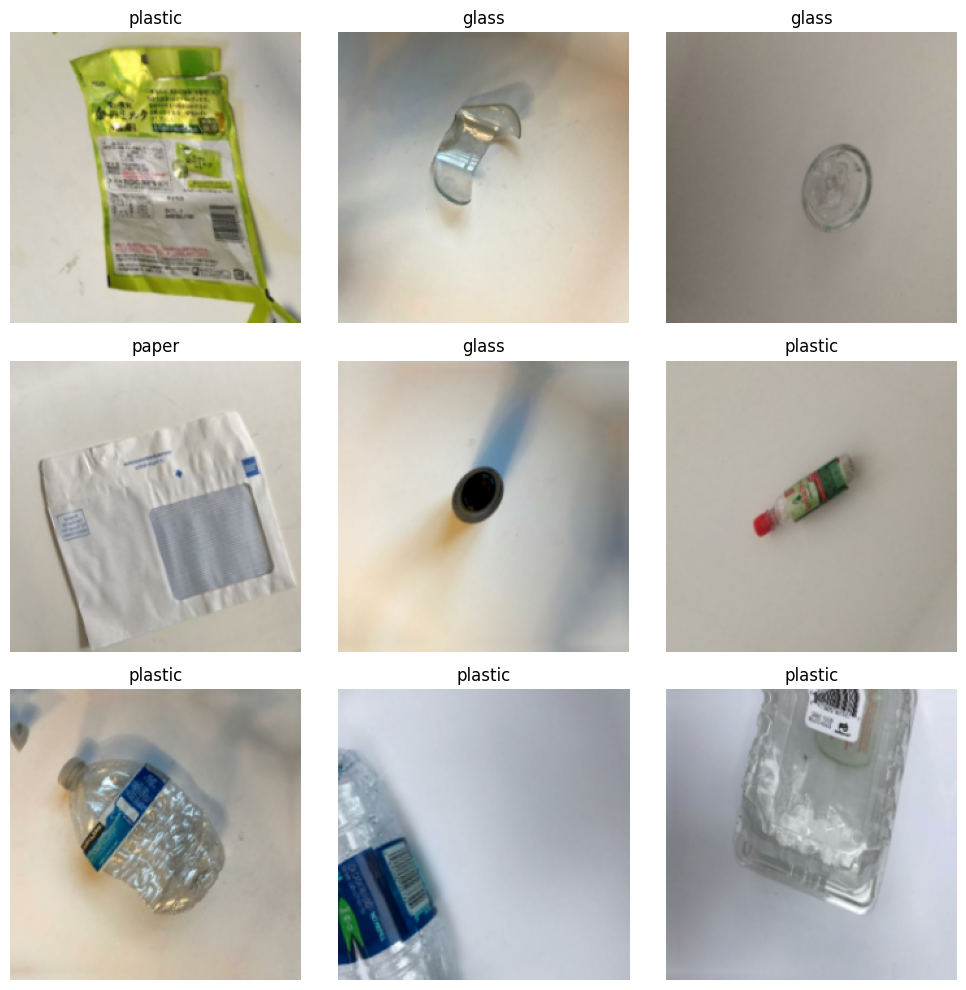

In [ ]:
for images, labels in train_ds_raw.take(1):
    aug_images = data_augmentation(images, training=True)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(aug_images[i], tf.uint8))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
def prepare_baseline_dataset(ds, training=False):
    def process(x, y):
        x = tf.cast(x, tf.float32) / 255.0
        if training:
            x = data_augmentation(x, training=True)
        return x, y
    return ds.map(process, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

def prepare_mobilenet_dataset(ds, training=False):
    def process(x, y):
        x = tf.cast(x, tf.float32)
        if training:
            x = data_augmentation(x, training=True)
        x = mobilenet_preprocess(x)
        return x, y
    return ds.map(process, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

def prepare_resnet_dataset(ds, training=False):
    def process(x, y):
        x = tf.cast(x, tf.float32)
        if training:
            x = data_augmentation(x, training=True)
        x = resnet_preprocess(x)
        return x, y
    return ds.map(process, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

train_ds_baseline = prepare_baseline_dataset(train_ds_raw, training=True)
val_ds_baseline = prepare_baseline_dataset(val_ds_raw, training=False)
test_ds_baseline = prepare_baseline_dataset(test_ds_raw, training=False)

train_ds_mobilenet = prepare_mobilenet_dataset(train_ds_raw, training=True)
val_ds_mobilenet = prepare_mobilenet_dataset(val_ds_raw, training=False)
test_ds_mobilenet = prepare_mobilenet_dataset(test_ds_raw, training=False)

train_ds_resnet = prepare_resnet_dataset(train_ds_raw, training=True)
val_ds_resnet = prepare_resnet_dataset(val_ds_raw, training=False)
test_ds_resnet = prepare_resnet_dataset(test_ds_raw, training=False)

## Training Callbacks

Early stopping and model checkpointing are used to reduce overfitting and save the best model weights.

In [ ]:
def get_callbacks(model_name):
    checkpoint_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True)
    ]

## Baseline CNN Implementation

In [ ]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ], name="Baseline_CNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn(input_shape=(224, 224, 3), num_classes=len(class_names))
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_baseline = baseline_model.fit(
    train_ds_baseline,
    validation_data=val_ds_baseline,
    epochs=20,
    callbacks=get_callbacks("baseline_cnn"),
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 519ms/step - accuracy: 0.3352 - loss: 1.6091 - val_accuracy: 0.4536 - val_loss: 1.3940
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 431ms/step - accuracy: 0.4032 - loss: 1.4193 - val_accuracy: 0.4907 - val_loss: 1.3090
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 412ms/step - accuracy: 0.4400 - loss: 1.3614 - val_accuracy: 0.3952 - val_loss: 1.4055
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.5159 - loss: 1.2384 - val_accuracy: 0.5279 - val_loss: 1.1872
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 414ms/step - accuracy: 0.5385 - loss: 1.2298 - val_accuracy: 0.5358 - val_loss: 1.2459
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.5521 - loss: 1.1557 - val_accuracy: 0.5332 - val_loss: 1.1814
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 442ms/step - accuracy: 0.5583 - loss: 1.1663 - val_accuracy: 0.5252 - val_loss: 1.1644
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 408ms/step - accuracy: 0.5493 - loss: 1.1533 - val_accu

## MobileNetV2 Transfer Learning Implementation

In [ ]:
def build_mobilenet_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenet_model((224, 224, 3), len(class_names))
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_mobilenet_initial = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=15,
    callbacks=get_callbacks("mobilenetv2_initial"),
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 78s 974ms/step - accuracy: 0.5493 - loss: 1.2009 - val_accuracy: 0.7533 - val_loss: 0.7240
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 434ms/step - accuracy: 0.7293 - loss: 0.7374 - val_accuracy: 0.7931 - val_loss: 0.6143
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 440ms/step - accuracy: 0.7633 - loss: 0.6166 - val_accuracy: 0.8249 - val_loss: 0.5502
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 402ms/step - accuracy: 0.7888 - loss: 0.5699 - val_accuracy: 0.8090 - val_loss: 0.5445
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.8041 - loss: 0.5391 - val_accuracy: 0.8064 - val_loss: 0.5510
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 398ms/step - accuracy: 0.8245 - loss: 0.4511 - val_accuracy: 0.8117 - val_loss: 0.5236
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 428ms/step - accuracy: 0.8409 - loss: 0.4164 - val_accuracy: 0.8223 - val_loss: 0.5267
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 422ms/step - accuracy: 0.8454 - loss: 0.4005 - val_accu

In [ ]:
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_mobilenet_fine = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=15,
    callbacks=get_callbacks("mobilenetv2_finetuned"),
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 742ms/step - accuracy: 0.7888 - loss: 0.6037 - val_accuracy: 0.8541 - val_loss: 0.4498
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 405ms/step - accuracy: 0.8177 - loss: 0.5069 - val_accuracy: 0.8541 - val_loss: 0.4427
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step - accuracy: 0.8080 - loss: 0.4804 - val_accuracy: 0.8647 - val_loss: 0.4418
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 443ms/step - accuracy: 0.8330 - loss: 0.4567 - val_accuracy: 0.8568 - val_loss: 0.4389
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 411ms/step - accuracy: 0.8567 - loss: 0.4205 - val_accuracy: 0.8594 - val_loss: 0.4342
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 423ms/step - accuracy: 0.8528 - loss: 0.4056 - val_accuracy: 0.8621 - val_loss: 0.4251
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 414ms/step - accuracy: 0.8579 - loss: 0.4095 - val_accuracy: 0.8594 - val_loss: 0.4196
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 414ms/step - accuracy: 0.8652 - loss: 0.3621 - val_accu

## ResNet50 Transfer Learning Implementation

In [ ]:
def build_resnet_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = ResNet50(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="ResNet50_Transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

resnet_model, resnet_base = build_resnet_model((224, 224, 3), len(class_names))
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet_initial = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=get_callbacks("resnet50_initial"),
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 720ms/step - accuracy: 0.6359 - loss: 1.0004 - val_accuracy: 0.8064 - val_loss: 0.5504
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 500ms/step - accuracy: 0.7831 - loss: 0.5708 - val_accuracy: 0.8329 - val_loss: 0.4595
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 497ms/step - accuracy: 0.8369 - loss: 0.4624 - val_accuracy: 0.8302 - val_loss: 0.4396
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 469ms/step - accuracy: 0.8607 - loss: 0.3873 - val_accuracy: 0.8329 - val_loss: 0.4413
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 468ms/step - accuracy: 0.8783 - loss: 0.3394 - val_accuracy: 0.8462 - val_loss: 0.4154
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 496ms/step - accuracy: 0.8703 - loss: 0.3454 - val_accuracy: 0.8727 - val_loss: 0.3679
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 501ms/step - accuracy: 0.8930 - loss: 0.2872 - val_accuracy: 0.8621 - val_loss: 0.3632
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 503ms/step - accuracy: 0.8992 - loss: 0.2743 - val_accu

In [ ]:
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet_fine = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=get_callbacks("resnet50_finetuned"),
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 70s 840ms/step - accuracy: 0.8715 - loss: 0.3582 - val_accuracy: 0.8992 - val_loss: 0.3212
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 506ms/step - accuracy: 0.9032 - loss: 0.2814 - val_accuracy: 0.9019 - val_loss: 0.3109
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step - accuracy: 0.9196 - loss: 0.2285 - val_accuracy: 0.8859 - val_loss: 0.3225
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 444ms/step - accuracy: 0.9292 - loss: 0.2034 - val_accuracy: 0.8806 - val_loss: 0.3232
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 464ms/step - accuracy: 0.9468 - loss: 0.1711 - val_accuracy: 0.8912 - val_loss: 0.3140
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 557ms/step - accuracy: 0.9536 - loss: 0.1448 - val_accuracy: 0.8939 - val_loss: 0.3162
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 480ms/step - accuracy: 0.9575 - loss: 0.1327 - val_accuracy: 0.8966 - val_loss: 0.3136


## Training Curve Visualization

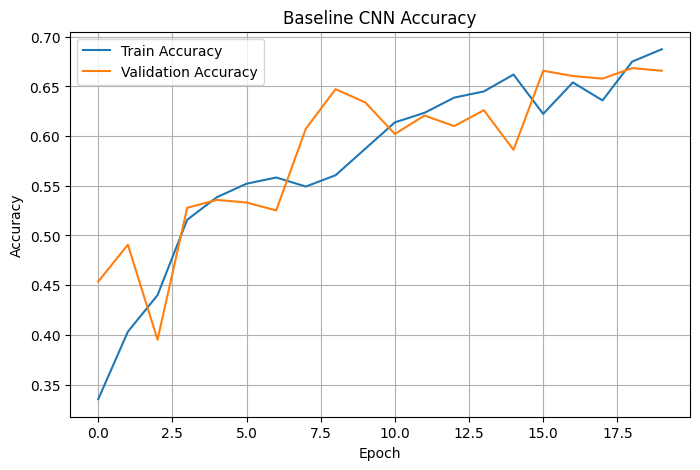

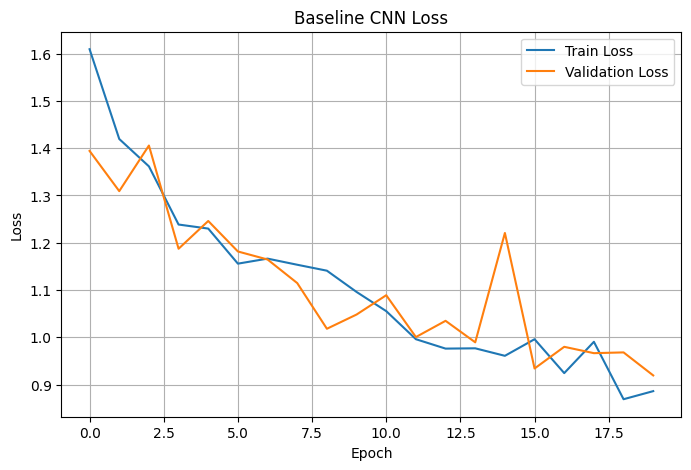

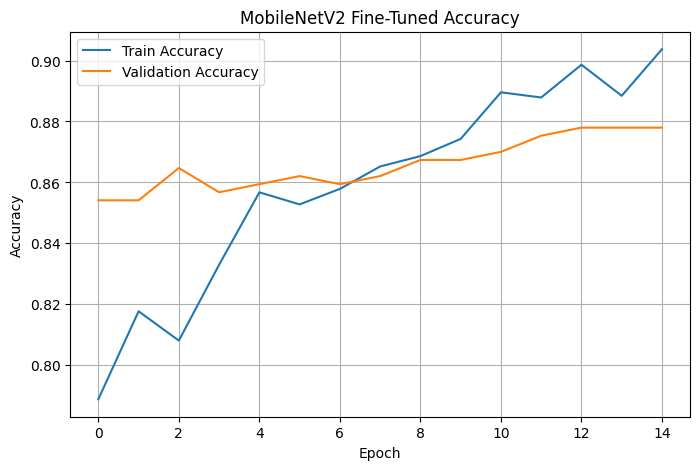

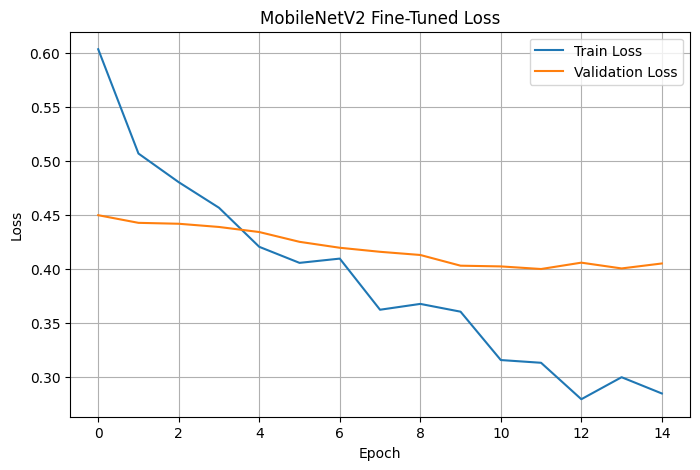

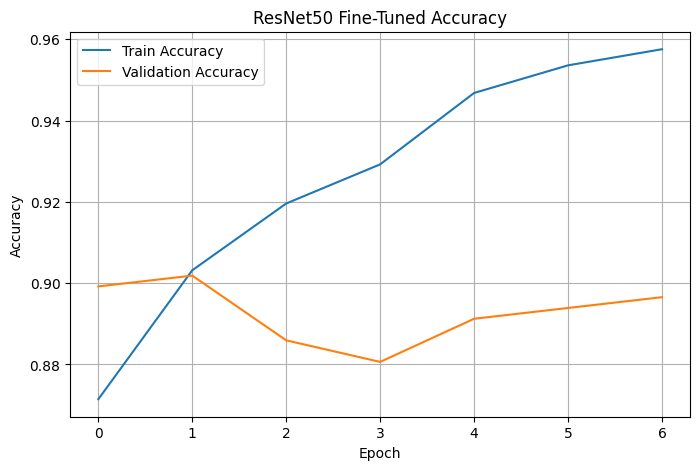

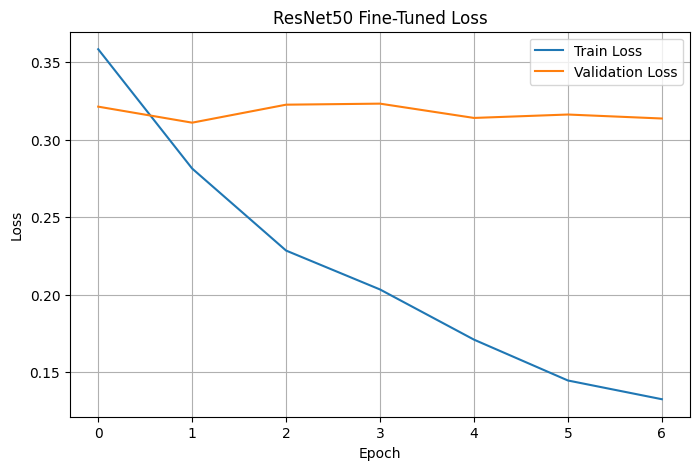

In [ ]:
def plot_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_baseline, "Baseline CNN")
plot_history(history_mobilenet_fine, "MobileNetV2 Fine-Tuned")
plot_history(history_resnet_fine, "ResNet50 Fine-Tuned")

## Evaluation Metrics and Model Testing

In [ ]:
def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, dataset, model_name):
    y_true, y_pred = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {model_name} =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

baseline_results = evaluate_model(baseline_model, test_ds_baseline, "Baseline CNN")
mobilenet_results = evaluate_model(mobilenet_model, test_ds_mobilenet, "MobileNetV2")
resnet_results = evaluate_model(resnet_model, test_ds_resnet, "ResNet50")


===== Baseline CNN =====
Accuracy : 0.609375
Precision: 0.6020058516394546
Recall   : 0.609375
F1-score : 0.5959712077351935

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.85      0.87      0.86        61
       glass       0.60      0.43      0.50        76
       metal       0.46      0.58      0.51        62
       paper       0.61      0.79      0.69        90
     plastic       0.60      0.53      0.57        73
       trash       0.29      0.09      0.14        22

    accuracy                           0.61       384
   macro avg       0.57      0.55      0.54       384
weighted avg       0.60      0.61      0.60       384


===== MobileNetV2 =====
Accuracy : 0.8619791666666666
Precision: 0.863161361809047
Recall   : 0.8619791666666666
F1-score : 0.8600677793234551

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.87      0.91        61
       glass       0.91      0

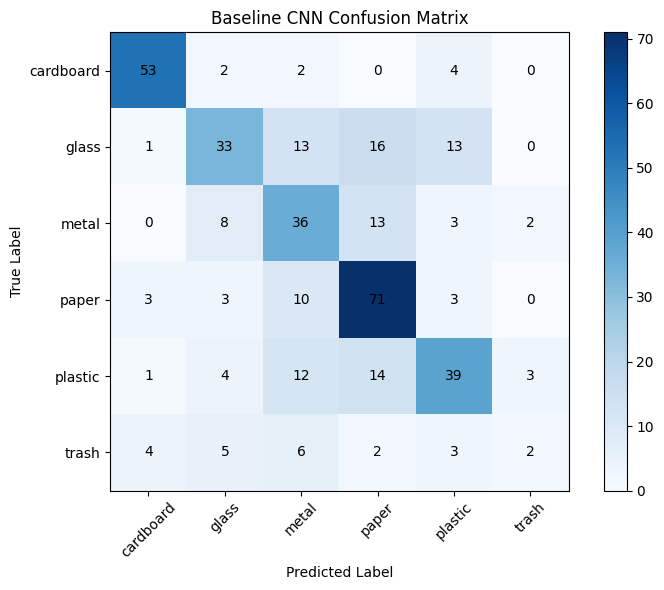

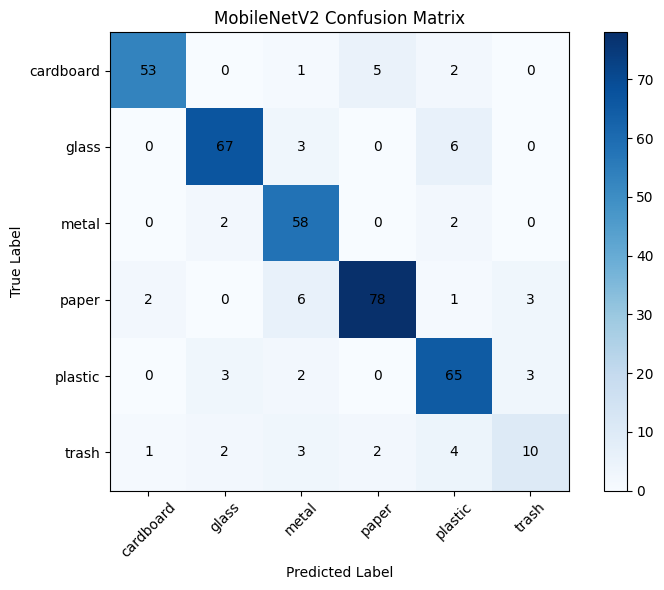

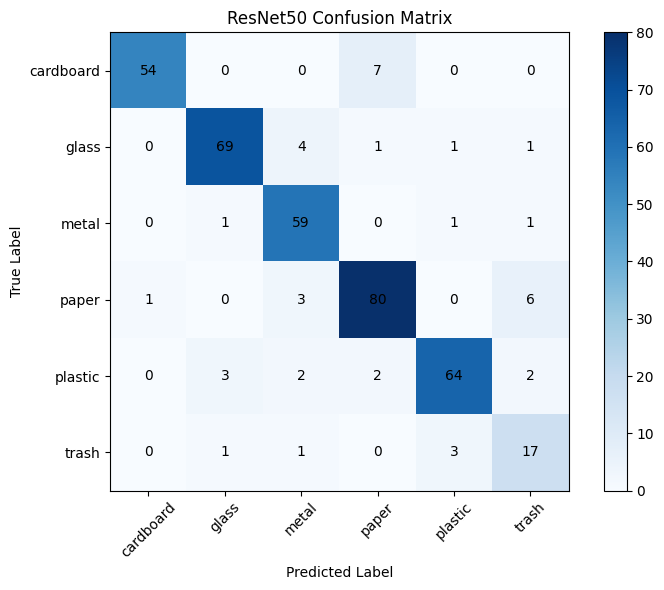

In [ ]:
plot_confusion_matrix(baseline_results["y_true"], baseline_results["y_pred"], class_names, "Baseline CNN Confusion Matrix")
plot_confusion_matrix(mobilenet_results["y_true"], mobilenet_results["y_pred"], class_names, "MobileNetV2 Confusion Matrix")
plot_confusion_matrix(resnet_results["y_true"], resnet_results["y_pred"], class_names, "ResNet50 Confusion Matrix")

## Final Model Comparison

In [ ]:
df_results = pd.DataFrame([
    {
        "Model": baseline_results["Model"],
        "Accuracy": baseline_results["Accuracy"],
        "Precision": baseline_results["Precision"],
        "Recall": baseline_results["Recall"],
        "F1-score": baseline_results["F1-score"]
    },
    {
        "Model": mobilenet_results["Model"],
        "Accuracy": mobilenet_results["Accuracy"],
        "Precision": mobilenet_results["Precision"],
        "Recall": mobilenet_results["Recall"],
        "F1-score": mobilenet_results["F1-score"]
    },
    {
        "Model": resnet_results["Model"],
        "Accuracy": resnet_results["Accuracy"],
        "Precision": resnet_results["Precision"],
        "Recall": resnet_results["Recall"],
        "F1-score": resnet_results["F1-score"]
    }
])

print(df_results)

          Model  Accuracy  Precision    Recall  F1-score
0  Baseline CNN  0.609375   0.602006  0.609375  0.595971
1   MobileNetV2  0.861979   0.863161  0.861979  0.860068
2      ResNet50  0.893229   0.899303  0.893229  0.894866


## Saving Outputs

In [ ]:
baseline_model.save(os.path.join(MODEL_DIR, "baseline_cnn_final.keras"))
mobilenet_model.save(os.path.join(MODEL_DIR, "mobilenetv2_final.keras"))
resnet_model.save(os.path.join(MODEL_DIR, "resnet50_final.keras"))

csv_path = os.path.join(REPORT_DIR, "final_model_comparison.csv")
df_results.to_csv(csv_path, index=False)

print("Models saved in:", MODEL_DIR)
print("Results CSV saved in:", csv_path)

Models saved in: /content/waste_phase2_project/outputs/models
Results CSV saved in: /content/waste_phase2_project/outputs/reports/final_model_comparison.csv


## Implementation Summary

This notebook demonstrates the full practical implementation of the AWCA system using the TrashNet dataset. The workflow includes dataset preparation, train-validation-test split, preprocessing, baseline CNN training, transfer learning with MobileNetV2 and ResNet50, and final evaluation using standard classification metrics.

In [ ]:
from google.colab import files
files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!git clone https://github.com/vaghaninayan/waste-classification-awca

Cloning into 'waste-classification-awca'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
%cd waste-classification-awca


/content/waste-classification-awca


In [ ]:
!ls /content

sample_data  waste-classification-awca
